# Dense in-context and few-shot model-fit plots

This notebook creates plot-only dense synthetic targets for visual inspection. It does not write into `data/raw` or `data/split`, and it should not be used for model fitting, hyperparameter selection, or reported metrics.

The in-context section reuses the actual saved training observations from the first five training tasks. 
The few-shot section uses new GP realizations generated with a separate seed so that leakage from the actual training data is prevented.

## Setup

In [1]:
from pathlib import Path
import sys
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate

from src.constants import (
    CONTEXT_ROLE_COLUMN_NAME,
    FIXED_EFFECT_PART_NAME,
    GROUPING_COLUMN_NAME,
    IN_CONTEXT_TASK_NAME,
    FEW_SHOT_TASK_NAME,
    NOISE_PART_NAME,
    RANDOM_EFFECT_PART_NAME,
    RESPONSE_COLUMN_NAME,
    SPLIT_COLUMN_NAME,
    SUPPORT_ROLE_NAME,
    SYNTHETIC_FEATURE_COLUMN_PREFIX,
    TARGET_ROLE_NAME,
    TEST_SPLIT_NAME,
    TRAIN_SPLIT_NAME,
    VALIDATION_SPLIT_NAME,
)
from src.data.synthetic_dense_prediction_data import (
    FEW_SHOT_IRRELEVANT_SEED,
    FEW_SHOT_NOISE_SEED,
    FEW_SHOT_RANDOM_EFFECT_SEED,
    FEW_SHOT_SUPPORT_SEED,
    GROUP_ID_OFFSET,
    IN_CONTEXT_DENSE_NOISE_SEED,
    PLOT_GENERATION_SEED,
    dense_few_shot_plot_split_df,
    dense_in_context_plot_split_df,
)
from src.evaluation.dense_tabicl_predictions import generate_dense_tabicl_prediction_frames
from src.data.data_layout import SyntheticDataLayout, PROJECT_ROOT, MODEL_FOLDER
from src.data.datasets import BundleFactory
from src.evaluation.crps import crps_score, gaussian_crps
from src.evaluation.model_predictions import GroupedModelPrediction
from src.plot.publication_plots import (
    MODEL_LABELS,
    plot_model_fit_prediction_columns,
    plot_in_context_split_reference,
)
from src.training.experiment_runner import (
    NPBoostExperiment,
    NPExperiment,
)
from src.utils.helpers import isolated_torch_rng


In [2]:
DATA_NAME = "gp_gaussian" # gp_gaussian, gp_gaussian_very_many_groups
FIXED_EFFECT_NAME = "steps_1D"
TASK_NAME = "few_shot"
IN_CONTEXT_PLOT_TASK_NAME = IN_CONTEXT_TASK_NAME
TRAINING_SPLIT_SEED = 0

N_TASKS = 3
N_SUPPORT = 20
N_QUERY = 400
MODEL_NAMES = ["np", "npboost", "anp", "anpboost"]
COMPARATIVE_MODEL_GROUPS = [["npboost", "np"], ["npboost"]]  # e.g. [["npboost", "np"], ["npboost"]]

INTERVAL_LEVEL = 0.95
INTERVAL_SAMPLES = 20
SHOW_GROUP_METRICS = True
DENSE_PLOT_LAYOUT = "model_columns"
COMPARATIVE_MODEL_GROUP_LAYOUT = "group_columns"
FEATURE = "feature_0"

SAVE_DIR = PROJECT_ROOT / "plots" / "publication_dense_model_predictions" / DATA_NAME
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def compose_task_config(task_name: str):
    if GlobalHydra.instance().is_initialized():
        GlobalHydra.instance().clear()
    with initialize_config_dir(version_base=None, config_dir=str(PROJECT_ROOT / "configs")):
        return compose(
        config_name="config",
        overrides=[
            f"data=synthetic/{DATA_NAME}",
            f"data/synthetic/fixed_effect={FIXED_EFFECT_NAME}",
            f"task={task_name}",
            f"data.experiment.split_data_seed={TRAINING_SPLIT_SEED}",
            "wandb.enabled=false",
            "device=cpu",
        ],
    )


cfg = compose_task_config(TASK_NAME)
in_context_cfg = compose_task_config(IN_CONTEXT_PLOT_TASK_NAME)
few_shot_cfg = compose_task_config(FEW_SHOT_TASK_NAME)
data_provider = instantiate(cfg.data.provider)
few_shot_task = instantiate(cfg.task)
in_context_task = instantiate(in_context_cfg.task)

assert data_provider.fixed_effect.feature_dimension == 1, "Dense line plots are 1D only."

data_provider.fixed_effect, data_provider.random_effect, data_provider.noise

(StepFixedEffect({'name': 'steps_1D', 'breaks': [array([-1. ,  0. ,  0.5])], 'values': array([ 3., -2.,  5., -1.]), 'multiplier': 0.3922322702763681}),
 RBFGPRandomEffect({'name': 'GP_rbf', 'alpha': 1e-06, 'length_scale': 0.5, 'variance': 1.0}),
 HomoscedasticGaussianNoise({'name': 'homoscedastic_gaussian', 'std': 0.5}))

## In-context: saved training context plus dense target grid

For in-context plots, the model conditions on the exact saved training observations from the first five training tasks. The dense target grid is generated only for plotting/prediction: it avoids the saved validation/test feature locations and extends the saved finite GP realization conditionally on the original saved random-effect values.


In [4]:
in_context_base_split_df = data_provider.fetch_split_df(
    task=in_context_task,
    seed=TRAINING_SPLIT_SEED,
)
in_context_raw_df = data_provider.fetch_raw_df(seed=TRAINING_SPLIT_SEED)
in_context_groups = sorted(
    in_context_base_split_df.loc[
        in_context_base_split_df[SPLIT_COLUMN_NAME] == TRAIN_SPLIT_NAME,
        GROUPING_COLUMN_NAME,
    ].unique()
)[:N_TASKS]

in_context_dense_split_df, in_context_recovery_diagnostics = dense_in_context_plot_split_df(
    data_provider,
    in_context_base_split_df,
    in_context_raw_df,
    groups=in_context_groups,
    seed=PLOT_GENERATION_SEED,
    noise_seed=IN_CONTEXT_DENSE_NOISE_SEED,
    n_query=N_QUERY,
    feature=FEATURE,
)

in_context_model_split_df = in_context_dense_split_df.drop(
    columns=["true_signal", "plot_generation_seed", "noise_generation_seed", "plot_only"],
    errors="ignore",
)
in_context_tabicl_model_split_df = pd.concat(
    [
        in_context_model_split_df[in_context_model_split_df[SPLIT_COLUMN_NAME] == TRAIN_SPLIT_NAME],
        in_context_model_split_df[in_context_model_split_df[SPLIT_COLUMN_NAME] == TEST_SPLIT_NAME],
    ],
    ignore_index=True,
    sort=False,
)
in_context_tabicl_bundle = BundleFactory.create_bundle(in_context_tabicl_model_split_df, in_context_task)
in_context_context_data = in_context_tabicl_bundle.train
in_context_target_data = in_context_tabicl_bundle.test

in_context_recovery_diagnostics


,group,effective_alpha,max_abs_deviation,random_effect_scale
0,0,0.000001,0.000421,1.024142
1,1,0.000001,0.000130,1.362587
2,2,0.000001,0.000201,1.022677


## In-context recovery sanity checks before model predictions

First plot the stored raw/split data for the first five tasks, with the exact training rows highlighted. Then plot the dense recovered plot-only data, again highlighting the same training context rows.  
They must match because for in-context evaluation, we want to use the same context points that were used for training.

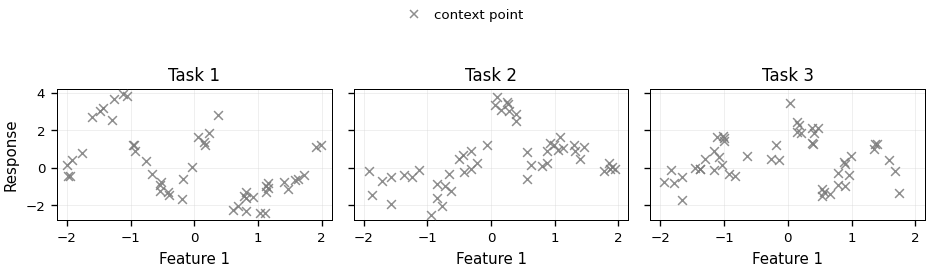

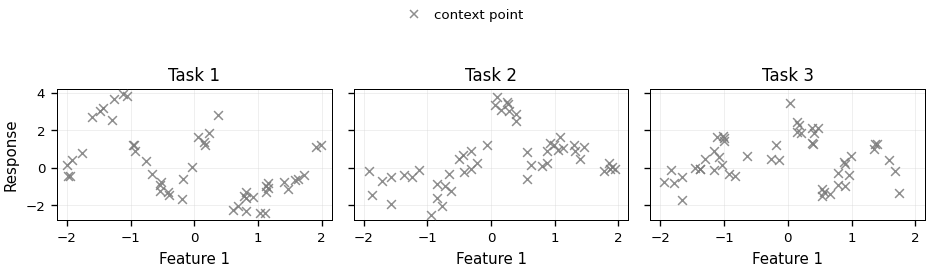

In [5]:
def shared_split_reference_limits(
    dataframes: list[pd.DataFrame],
    *,
    groups: list[int],
    feature: str,
    split_names: tuple[str, ...],
    pad_fraction: float = 0.04,
) -> tuple[tuple[float, float], tuple[float, float]]:
    selected = []
    for df in dataframes:
        mask = df[GROUPING_COLUMN_NAME].isin(groups) & df[SPLIT_COLUMN_NAME].isin(split_names)
        selected.append(df.loc[mask, [feature, RESPONSE_COLUMN_NAME]])
    values = pd.concat(selected, ignore_index=True)
    x_min, x_max = values[feature].min(), values[feature].max()
    y_min, y_max = values[RESPONSE_COLUMN_NAME].min(), values[RESPONSE_COLUMN_NAME].max()
    x_pad = max((x_max - x_min) * pad_fraction, 1e-9)
    y_pad = max((y_max - y_min) * pad_fraction, 1e-9)
    return (x_min - x_pad, x_max + x_pad), (y_min - y_pad, y_max + y_pad)


in_context_reference_split_names = (TRAIN_SPLIT_NAME,)
in_context_reference_xlim, in_context_reference_ylim = shared_split_reference_limits(
    [in_context_base_split_df, in_context_dense_split_df],
    groups=in_context_groups,
    feature=FEATURE,
    split_names=in_context_reference_split_names,
)

# The context points that were provided during training
in_context_raw_reference_path = SAVE_DIR / (
    f"{FIXED_EFFECT_NAME}-in_context-raw-split.pdf"
)
fig, axes = plot_in_context_split_reference(
    in_context_base_split_df,
    groups=in_context_groups,
    feature=FEATURE,
    split_names=in_context_reference_split_names,
    xlim=in_context_reference_xlim,
    ylim=in_context_reference_ylim,
    save_path=in_context_raw_reference_path,
    show=False,
)

# The context points provided for the dense prediction plots
in_context_dense_reference_path = SAVE_DIR / (
    f"{FIXED_EFFECT_NAME}-in_context-dense_extended.pdf"
)
fig, axes = plot_in_context_split_reference(
    in_context_dense_split_df,
    groups=in_context_groups,
    feature=FEATURE,
    split_names=in_context_reference_split_names,
    xlim=in_context_reference_xlim,
    ylim=in_context_reference_ylim,
    save_path=in_context_dense_reference_path,
    show=False,
)

In [6]:
MODEL_LOADERS = {
    "np": NPExperiment.load_model,
    "anp": NPExperiment.load_model,
    "npboost": NPBoostExperiment.load_model,
    "anpboost": NPBoostExperiment.load_model,
}


def load_saved_model_for_task(model_name: str, task):
    model_folder, model_file_name = SyntheticDataLayout.get_model_path(
        experiment_name=DATA_NAME,
        model_name=model_name,
        fixed_effect_name=FIXED_EFFECT_NAME,
        task=task,
        split_data_seed=TRAINING_SPLIT_SEED,
    )


    model = MODEL_LOADERS[model_name](model_folder, model_file_name)
    if hasattr(model, "device"):
        model.device = torch.device("cpu")
    if hasattr(model, "np_trainer"):
        model.np_trainer.device = torch.device("cpu")
    if hasattr(model, "npboost"):
        model.npboost.device = torch.device("cpu")
        model.npboost.np_trainer.device = torch.device("cpu")
    return model


def _distribution_device(distribution: torch.distributions.Distribution) -> torch.device | None:
    try:
        mean = distribution.mean
    except NotImplementedError:
        return None
    return mean.device if isinstance(mean, torch.Tensor) else None


def _sample_distribution(distribution: torch.distributions.Distribution, sample_shape: torch.Size, seed: int) -> torch.Tensor:
    with isolated_torch_rng(seed, device=_distribution_device(distribution)):
        return distribution.sample(sample_shape)


def _as_flat_samples(samples: torch.Tensor) -> np.ndarray:
    samples = torch.flatten(samples, start_dim=0, end_dim=1).squeeze(-1)
    if samples.ndim == 3 and samples.shape[1] == 1:
        samples = samples.squeeze(1)
    if samples.ndim > 2:
        samples = samples.reshape(samples.shape[0], -1)
    if samples.ndim == 1:
        samples = samples.reshape(1, -1)
    return samples.detach().cpu().numpy()


def _add_gaussian_group_metrics(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    group_rmse = np.full(len(frame), np.nan)
    group_crps = np.full(len(frame), np.nan)
    group_ids = frame["group_id"].to_numpy()
    for group_id in pd.unique(group_ids):
        group_mask = group_ids == group_id
        y_g = frame.loc[group_mask, "y_true"].to_numpy(dtype=float)
        mean_g = frame.loc[group_mask, "mean"].to_numpy(dtype=float)
        std_g = np.clip(frame.loc[group_mask, "std"].to_numpy(dtype=float), a_min=1e-12, a_max=None)
        group_rmse[group_mask] = float(np.sqrt(np.mean((mean_g - y_g) ** 2)))
        if np.isfinite(std_g).all():
            group_crps[group_mask] = float(gaussian_crps(y_g, mean_g, std_g))
    frame["group_rmse"] = group_rmse
    frame["group_crps"] = group_crps
    return frame


def prediction_frame_from_model(
    model_name: str,
    model,
    *,
    target_data,
    context_data,
    feature: str,
    interval_level: float,
    interval_samples: int,
    seed: int,
) -> pd.DataFrame:
    if hasattr(model, "_set_prediction_seed"):
        model._set_prediction_seed(TEST_SPLIT_NAME)

    predictions = model.predict(target_data=target_data, context_data=context_data)
    pred = predictions.reorder_to_original() if isinstance(predictions, GroupedModelPrediction) else predictions
    n_rows = len(target_data.response)

    fixed = np.full(n_rows, np.nan)
    random = np.full(n_rows, np.nan)
    if pred.fixed_effect is not None:
        fixed = np.asarray(pred.fixed_effect).reshape(-1)
    if pred.random_effect is not None:
        random = np.asarray(pred.random_effect).reshape(-1)

    frame = pd.DataFrame(
        {
            "row_index": np.arange(n_rows),
            "group_id": np.asarray(pred.group_ids).reshape(-1),
            "model_name": model_name,
            "model_label": MODEL_LABELS.get(model_name, model_name),
            feature: target_data.features[feature].to_numpy(),
            "y_true": target_data.response.to_numpy(),
            "mean": np.asarray(pred.mean).reshape(-1),
            "std": np.clip(np.asarray(pred.std).reshape(-1), a_min=0.0, a_max=None),
            "fixed_effect": fixed,
            "random_effect": random,
            "true_fixed_effect": target_data.fixed_effect_part.to_numpy(),
            "true_random_effect": target_data.random_effect_part.to_numpy(),
            "true_noise": target_data.noise_part.to_numpy(),
        }
    )
    frame["true_signal"] = frame["true_fixed_effect"] + frame["true_random_effect"]

    lower_col = f"lower_{interval_level:.2f}"
    upper_col = f"upper_{interval_level:.2f}"
    if isinstance(predictions, GroupedModelPrediction) and predictions.predictive_distributions:
        lower = np.full(n_rows, np.nan)
        upper = np.full(n_rows, np.nan)
        group_rmse = np.full(n_rows, np.nan)
        group_crps = np.full(n_rows, np.nan)
        group_ids = frame["group_id"].to_numpy()
        for group_index, (group_id, distribution) in enumerate(pred.predictive_distributions.items()):
            group_mask = group_ids == group_id
            if not np.any(group_mask):
                continue
            samples = _sample_distribution(distribution, torch.Size([interval_samples]), seed=seed + group_index)
            samples_np = _as_flat_samples(samples)
            alpha = 1.0 - interval_level
            lower[group_mask] = np.quantile(samples_np, q=alpha / 2, axis=0)
            upper[group_mask] = np.quantile(samples_np, q=1.0 - alpha / 2, axis=0)
            y_g = frame.loc[group_mask, "y_true"].to_numpy(dtype=float)
            mean_g = frame.loc[group_mask, "mean"].to_numpy(dtype=float)
            group_rmse[group_mask] = float(np.sqrt(np.mean((mean_g - y_g) ** 2)))
            group_crps[group_mask] = float(
                crps_score(
                    torch.as_tensor(samples_np, dtype=torch.float32),
                    torch.as_tensor(y_g, dtype=torch.float32),
                ).mean().item()
            )
        frame[lower_col] = lower
        frame[upper_col] = upper
        frame["group_rmse"] = group_rmse
        frame["group_crps"] = group_crps
        frame["interval_method"] = "sample_quantile"
    else:
        z_score = NormalDist().inv_cdf(0.5 + interval_level / 2)
        frame[lower_col] = frame["mean"] - z_score * frame["std"]
        frame[upper_col] = frame["mean"] + z_score * frame["std"]
        frame = _add_gaussian_group_metrics(frame)
        frame["interval_method"] = "gaussian_mean_std"

    return frame


in_context_models = {
    model_name: load_saved_model_for_task(model_name, in_context_task)
    for model_name in MODEL_NAMES
}
list(in_context_models)

Model was trained on GPU but no GPU is available. Loading on CPU instead.
Model was trained on GPU but no GPU is available. Loading on CPU instead.
Model was trained on GPU but no GPU is available. Loading on CPU instead.
Model was trained on GPU but no GPU is available. Loading on CPU instead.


['np', 'npboost', 'anp', 'anpboost']

In [7]:
in_context_context_df = in_context_dense_split_df[in_context_dense_split_df[SPLIT_COLUMN_NAME] == TRAIN_SPLIT_NAME]
in_context_target_df = in_context_dense_split_df[in_context_dense_split_df[SPLIT_COLUMN_NAME] == TEST_SPLIT_NAME]
in_context_point_df = pd.DataFrame(
    {
        "group_id": in_context_context_df[GROUPING_COLUMN_NAME],
        FEATURE: in_context_context_df[FEATURE],
        "y": in_context_context_df[RESPONSE_COLUMN_NAME],
        "PointType": "Context",
    }
)

in_context_prediction_df = pd.concat(
    [
        prediction_frame_from_model(
            model_name,
            model,
            target_data=in_context_target_data,
            context_data=in_context_context_data,
            feature=FEATURE,
            interval_level=INTERVAL_LEVEL,
            interval_samples=INTERVAL_SAMPLES,
            seed=PLOT_GENERATION_SEED,
        )
        for model_name, model in in_context_models.items()
    ],
    ignore_index=True,
)

in_context_point_df.shape, in_context_prediction_df.shape

((150, 4), (4800, 19))

## TabICL in-context predictions

In [8]:
# Runs for 40 minutes if LOAD_DENSE_TABICL_PREDICTIONS_FROM_DISK is False.
LOAD_DENSE_TABICL_PREDICTIONS_FROM_DISK = True
DENSE_TABICL_PREDICTION_DIR = MODEL_FOLDER / DATA_NAME / FIXED_EFFECT_NAME

TABICL_MODEL_LABELS = {
    "tabicl_taskwise": "TabICL_T",
    "tabicl_pooled": "TabICL_P",
}
TABICL_MODEL_NAMES = ["tabicl_taskwise", "tabicl_pooled"]
TABICL_N_ESTIMATORS = 8

MODEL_LABELS.update(TABICL_MODEL_LABELS)
DENSE_MODEL_NAMES = [*MODEL_NAMES, *TABICL_MODEL_NAMES]


def dense_tabicl_prediction_path(task_name: str) -> Path:
    return DENSE_TABICL_PREDICTION_DIR / f"dense_model_predictions-{task_name}-seed{TRAINING_SPLIT_SEED}.parquet"


def load_dense_tabicl_prediction_df(task_name: str) -> pd.DataFrame:
    prediction_path = dense_tabicl_prediction_path(task_name)
    if not prediction_path.exists():
        raise FileNotFoundError(
            f"Missing dense TabICL predictions at {prediction_path}. "
            "Run scripts/bash_scripts/synthetic_experiments/gp_gaussian/dense_tabicl_predictions.sh first, "
            "or set LOAD_DENSE_TABICL_PREDICTIONS_FROM_DISK = False."
        )
    return pd.read_parquet(prediction_path)


def generate_dense_tabicl_prediction_df(task_name: str) -> pd.DataFrame:

    return generate_dense_tabicl_prediction_frames(
        data_name=DATA_NAME,
        fixed_effect_name=FIXED_EFFECT_NAME,
        split_seed=TRAINING_SPLIT_SEED,
        tasks=(task_name,),
        model_names=TABICL_MODEL_NAMES,
        n_tasks=N_TASKS,
        n_support=N_SUPPORT,
        n_query=N_QUERY,
        group_id_offset=GROUP_ID_OFFSET,
        interval_level=INTERVAL_LEVEL,
        n_estimators=TABICL_N_ESTIMATORS,
        n_jobs=1,
        save=False,
    )[task_name]


def _dense_model_group_slug(model_names):
    return "-vs-".join(str(model_name) for model_name in model_names)


def save_dense_model_group_plots(
    *,
    prediction_df,
    point_df,
    point_label="context point",
    model_groups,
    task_name,
    groups,
    show_group_metrics,
    layout,
    legend_fontsize=10,
    legend_handle_scale=1.0,
    legend_ncol=None,
):
    paths = []
    available_models = set(prediction_df["model_name"].astype(str))
    for model_group in model_groups:
        model_group = [str(model_name) for model_name in model_group]
        if not model_group:
            continue
        missing = [model_name for model_name in model_group if model_name not in available_models]
        if missing:
            raise ValueError(f"Unknown dense model comparison entries: {missing}")
        path = SAVE_DIR / (
            f"{FIXED_EFFECT_NAME}-{task_name}-dense-{_dense_model_group_slug(model_group)}.pdf"
        )
        fig, axes = plot_model_fit_prediction_columns(
            prediction_df=prediction_df,
            point_df=point_df,
            point_label=point_label,
            model_names=model_group,
            groups=groups,
            feature=FEATURE,
            interval_level=INTERVAL_LEVEL,
            show_group_metrics=show_group_metrics,
            layout=layout,
            save_path=path,
            show=False,
            legend_fontsize=legend_fontsize,
            legend_handle_scale=legend_handle_scale,
            legend_ncol=legend_ncol,
        )
        plt.close(fig)
        paths.append(path)
    return paths

if LOAD_DENSE_TABICL_PREDICTIONS_FROM_DISK:
    in_context_tabicl_prediction_df = load_dense_tabicl_prediction_df(IN_CONTEXT_TASK_NAME)
else:
    in_context_tabicl_prediction_df = generate_dense_tabicl_prediction_df(IN_CONTEXT_TASK_NAME)
in_context_prediction_df = pd.concat(
    [in_context_prediction_df, in_context_tabicl_prediction_df],
    ignore_index=True,
)

in_context_point_df.shape, in_context_prediction_df.shape

((150, 4), (7200, 20))

## In-context final plot: NP-family models plus TabICL variants by task


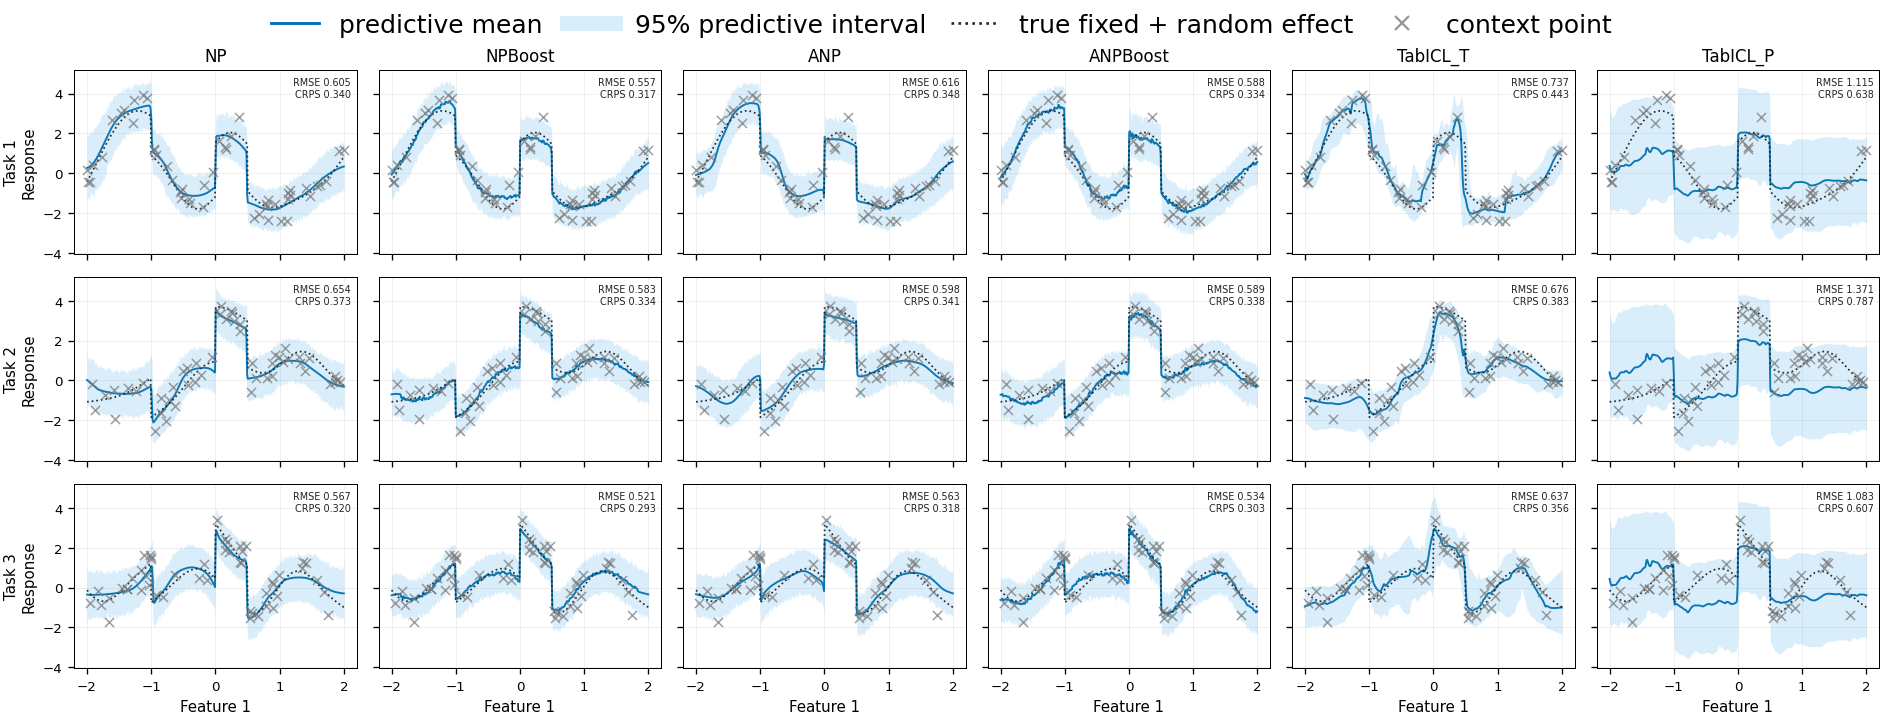

In [9]:
in_context_plot_path = SAVE_DIR / (
    f"{FIXED_EFFECT_NAME}-in_context-dense-tabicl.pdf"
)
fig, axes = plot_model_fit_prediction_columns(
    in_context_prediction_df,
    point_df=in_context_point_df,
    point_label="context point",
    model_names=DENSE_MODEL_NAMES,
    groups=in_context_groups,
    feature=FEATURE,
    interval_level=INTERVAL_LEVEL,
    show_group_metrics=SHOW_GROUP_METRICS,
    layout=DENSE_PLOT_LAYOUT,
    save_path=in_context_plot_path,
    show=False,
    legend_fontsize=15,
    legend_ncol=4,
    legend_handle_scale=1.5,
)

in_context_comparison_plot_paths = save_dense_model_group_plots(
    prediction_df=in_context_prediction_df,
    point_df=in_context_point_df,
    point_label="context point",
    model_groups=COMPARATIVE_MODEL_GROUPS,
    task_name="in_context",
    groups=in_context_groups,
    show_group_metrics=SHOW_GROUP_METRICS,
    layout=COMPARATIVE_MODEL_GROUP_LAYOUT,
    legend_fontsize=7,
);

## Few-shot: generate dense plot-only tasks

In [10]:
dense_split_df = dense_few_shot_plot_split_df(
    data_provider,
    random_effect_seed=FEW_SHOT_RANDOM_EFFECT_SEED,
    noise_seed=FEW_SHOT_NOISE_SEED,
    support_seed=FEW_SHOT_SUPPORT_SEED,
    irrelevant_seed=FEW_SHOT_IRRELEVANT_SEED,
    n_tasks=N_TASKS,
    n_support=N_SUPPORT,
    n_query=N_QUERY,
    group_id_offset=GROUP_ID_OFFSET,
)

training_split_df = data_provider.fetch_split_df(task=few_shot_task, seed=TRAINING_SPLIT_SEED)
training_groups = set(
    training_split_df.loc[
        training_split_df[SPLIT_COLUMN_NAME] == TRAIN_SPLIT_NAME,
        GROUPING_COLUMN_NAME,
    ].unique()
)
plot_groups = set(dense_split_df[GROUPING_COLUMN_NAME].unique())
assert plot_groups.isdisjoint(training_groups)
assert FEW_SHOT_RANDOM_EFFECT_SEED > 10_000_000
assert FEW_SHOT_NOISE_SEED > 10_000_000
assert FEW_SHOT_SUPPORT_SEED > 10_000_000
assert np.allclose(
    dense_split_df[RESPONSE_COLUMN_NAME],
    dense_split_df[FIXED_EFFECT_PART_NAME]
    + dense_split_df[RANDOM_EFFECT_PART_NAME]
    + dense_split_df[NOISE_PART_NAME],
)

model_split_df = dense_split_df.drop(
    columns=[
        "true_signal",
        "plot_generation_seed",
        "random_effect_generation_seed",
        "noise_generation_seed",
        "support_generation_seed",
        "plot_only",
    ],
    errors="ignore",
)
dense_bundle = BundleFactory.create_bundle(model_split_df, few_shot_task)
training_bundle = BundleFactory.create_bundle(training_split_df, few_shot_task)
context_data = dense_bundle.test_support
target_data = dense_bundle.test_query
tabicl_train_data = training_bundle.train
assert len(tabicl_train_data.response) > 0

dense_split_df.groupby([GROUPING_COLUMN_NAME, CONTEXT_ROLE_COLUMN_NAME]).size().unstack()

context_role,SUPPORT,TARGET
group,,
100000,20,400
100001,20,400
100002,20,400


## Load the fitted NP-family models

In [11]:
models = {model_name: load_saved_model_for_task(model_name, few_shot_task) for model_name in MODEL_NAMES}
list(models)

Model was trained on GPU but no GPU is available. Loading on CPU instead.
Model was trained on GPU but no GPU is available. Loading on CPU instead.
Model was trained on GPU but no GPU is available. Loading on CPU instead.
Model was trained on GPU but no GPU is available. Loading on CPU instead.


['np', 'npboost', 'anp', 'anpboost']

## Predict and build dense plot frames

`point_df` contains only the support rows so final few-shot plots do not draw target points. The dense target grid is used for model predictions and for the latent truth curve.


In [12]:
support_df = dense_split_df[dense_split_df[CONTEXT_ROLE_COLUMN_NAME] == SUPPORT_ROLE_NAME]
target_df = dense_split_df[dense_split_df[CONTEXT_ROLE_COLUMN_NAME] == TARGET_ROLE_NAME]
point_df = pd.DataFrame(
    {
        "group_id": support_df[GROUPING_COLUMN_NAME],
        FEATURE: support_df[FEATURE],
        "y": support_df[RESPONSE_COLUMN_NAME],
        "PointType": "Support",
    }
)

prediction_df = pd.concat(
    [
        prediction_frame_from_model(
            model_name,
            model,
            target_data=target_data,
            context_data=context_data,
            feature=FEATURE,
            interval_level=INTERVAL_LEVEL,
            interval_samples=INTERVAL_SAMPLES,
            seed=PLOT_GENERATION_SEED,
        )
        for model_name, model in models.items()
    ],
    ignore_index=True,
)

point_df.shape, prediction_df.shape


((60, 4), (4800, 19))

## TabICL few-shot predictions


In [13]:
if LOAD_DENSE_TABICL_PREDICTIONS_FROM_DISK:
    tabicl_prediction_df = load_dense_tabicl_prediction_df(TASK_NAME)
else:
    tabicl_prediction_df = generate_dense_tabicl_prediction_df(TASK_NAME)
prediction_df = pd.concat([prediction_df, tabicl_prediction_df], ignore_index=True)

point_df.shape, prediction_df.shape

((60, 4), (7200, 20))

## Final few-shot plot

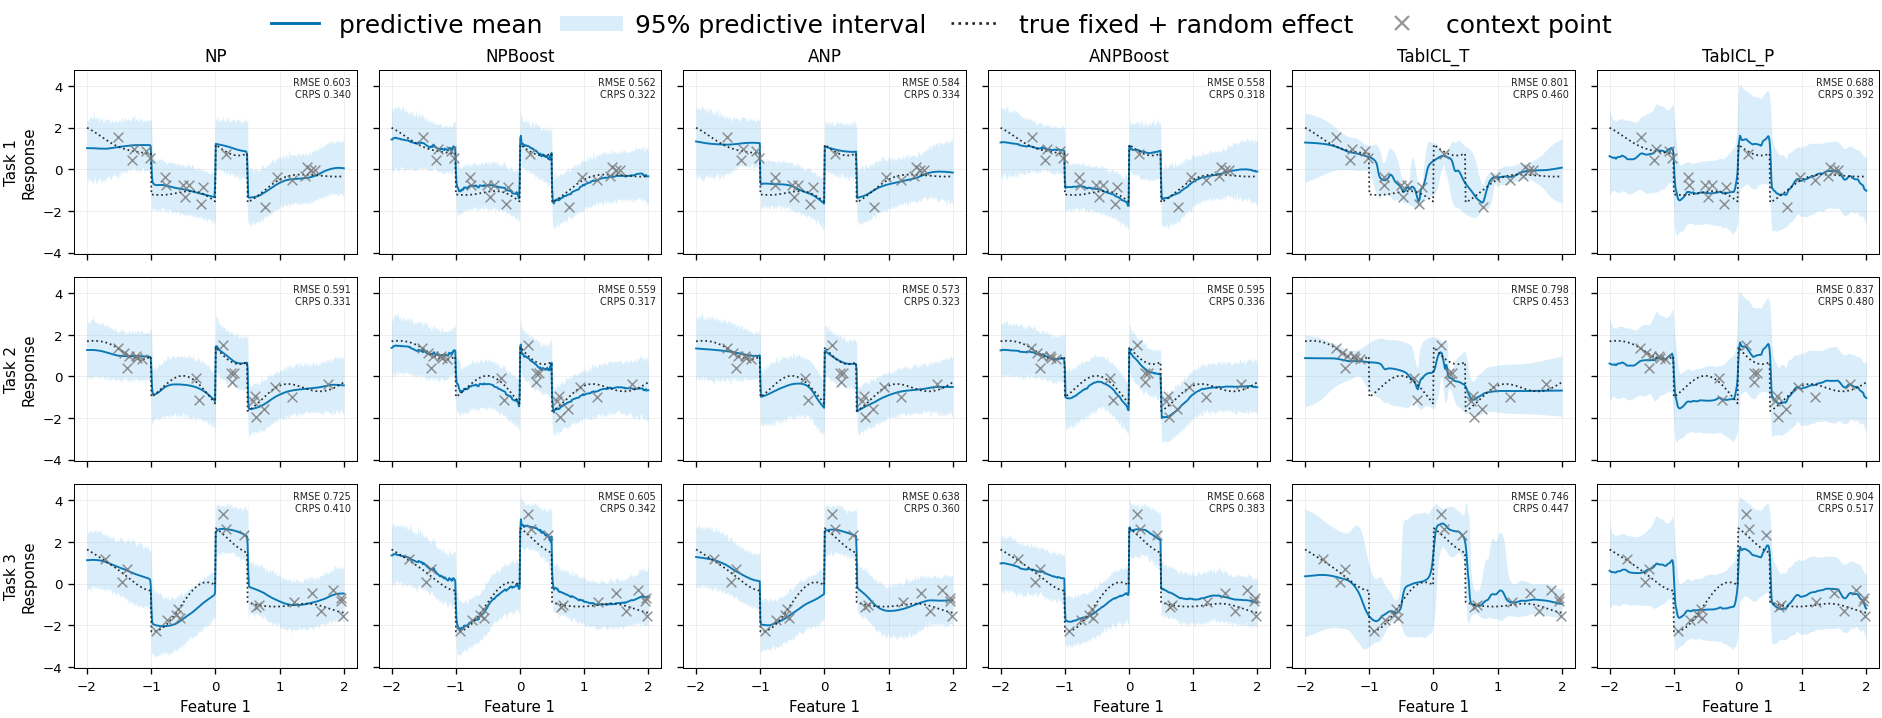

In [14]:
selected_groups = sorted(dense_split_df[GROUPING_COLUMN_NAME].unique())[:N_TASKS]
sample_plot_path = SAVE_DIR / (
    f"{FIXED_EFFECT_NAME}-{TASK_NAME}-dense-tabicl.pdf"
)
fig, axes = plot_model_fit_prediction_columns(
    prediction_df,
    point_df=point_df,
    point_label="context point",
    model_names=DENSE_MODEL_NAMES,
    groups=selected_groups,
    feature=FEATURE,
    interval_level=INTERVAL_LEVEL,
    show_group_metrics=SHOW_GROUP_METRICS,
    layout=DENSE_PLOT_LAYOUT,
    save_path=sample_plot_path,
    show=False,
    legend_fontsize=15,
    legend_ncol=4,
    legend_handle_scale=1.5,
)

comparison_plot_paths = save_dense_model_group_plots(
    prediction_df=prediction_df,
    point_df=point_df,
    point_label="context point",
    model_groups=COMPARATIVE_MODEL_GROUPS,
    task_name=TASK_NAME,
    groups=selected_groups,
    show_group_metrics=SHOW_GROUP_METRICS,
    layout=COMPARATIVE_MODEL_GROUP_LAYOUT,
    legend_fontsize=7
);
